In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import linalg as la
from tqdm import tqdm
import pickle

import kwant

from koala import plotting as pl

from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)
from alter_morph.hamiltonians import (
    alt_hamiltonian,
    spectral_function,
    _hopping_matrix,
    find_m_per_state,
    find_spin_per_state,
)
from alter_morph.mean_field import hartree_fock

matplotlib.rcParams.update(
    {
        "font.size": 11,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)

some functions:

In [63]:
def fermi_level(energies, filling):
    return np.mean(
        energies[int(filling * len(energies)) - 1 : int(filling * len(energies)) + 1]
    )


def dos_at_fermi(energies, fermi_energy, broadening):
    norm_lorenzian = (1 / np.pi) * (
        broadening / ((energies - fermi_energy) ** 2 + broadening**2)
    )
    return np.mean(norm_lorenzian)


def real_space_density_around_fermi(energies, states, fermi_energy, broadening):
    norm_lorenzian = (1 / np.pi) * (
        broadening / ((energies - fermi_energy) ** 2 + broadening**2)
    )

    densities = np.abs(states) ** 2 * norm_lorenzian[None, :]
    return np.sum(densities, axis=1).reshape(-1, 4).sum(axis=-1)

In [17]:
data_name = "data/full_phase_diagram_20_n_V1"

# load data
with open(data_name + ".pickle", "rb") as f:
    data = pickle.load(f)

# load lattice
with open("analysis/voronoi_20.pickle", "rb") as f:
    lattice = pickle.load(f)

In [18]:
# process the data

fillings = data["filling"]
J_vals = data["J"]

all_avg_mags = np.zeros([len(fillings), len(J_vals)])
all_energies = np.zeros([len(fillings), len(J_vals), lattice.n_vertices * 4])

broadening = 0.01
all_dos_vals = np.zeros([len(fillings), len(J_vals)])

all_bond_diff_m = np.zeros([len(fillings), len(J_vals)])
all_bond_diff_n = np.zeros([len(fillings), len(J_vals)])

for i, filling in enumerate(tqdm(fillings)):
    for j, J in enumerate(J_vals):
        current_data = data["params"][i, j]

        # calculate the average magnetization
        all_avg_mags[i, j] = np.mean(current_data["m"])

        # calculate the energies
        ham = alt_hamiltonian(
            lattice,
            current_data["t1"],
            current_data["t2"],
            current_data["J"],
            current_data["U"],
            current_data["m"],
            current_data["n"],
        )
        all_energies[i, j] = la.eigvalsh(ham)

        # calculate the density of states
        all_dos_vals[i, j] = dos_at_fermi(
            all_energies[i, j], fermi_level(all_energies[i, j], filling), broadening
        )

        # difference in m on bonds
        m = data["params"][i, j]["m"]
        m_on_bonds = m[lattice.edges.indices]
        all_bond_diff_m[i, j] = np.abs(m_on_bonds[:, 0] - m_on_bonds[:, 1]).mean()

        # difference in n on bonds
        n = data["params"][i, j]["n"]
        n_on_bonds = n[lattice.edges.indices]
        all_bond_diff_n[i, j] = np.abs(n_on_bonds[:, 0] - n_on_bonds[:, 1]).mean()

# save the processed data
with open(data_name + "_processed.pickle", "wb") as f:
    pickle.dump(
        {
            "fillings": fillings,
            "J_vals": J_vals,
            "all_avg_mags": all_avg_mags,
            "all_energies": all_energies,
            "all_dos_vals": all_dos_vals,
            "all_bond_diff_m": all_bond_diff_m,
            "all_bond_diff_n": all_bond_diff_n,
        },
        f,
    )

  0%|          | 0/21 [00:00<?, ?it/s]

100%|██████████| 21/21 [09:30<00:00, 27.19s/it]


Plot the phase diagram

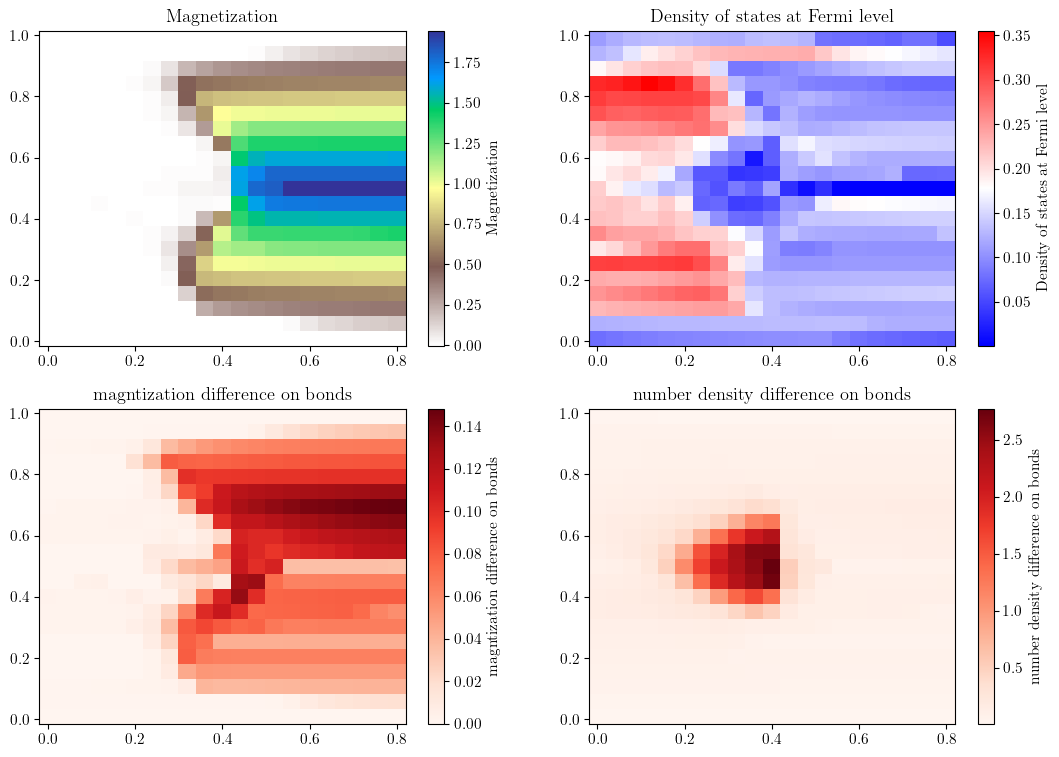

In [ ]:
J, FIL = np.meshgrid(J_vals, fillings)


fig, ax = plt.subplots(2, 2, figsize=(13, 9))
ax = ax.flatten()

im0 = ax[0].pcolor(J, FIL, all_avg_mags, cmap="terrain_r")
ax[0].set_title("Magnetization")

im1 = ax[1].pcolor(J, FIL, all_dos_vals, cmap="bwr")
ax[1].set_title("Density of states at Fermi level")

im2 = ax[2].pcolor(J, FIL, all_bond_diff_m, cmap="Reds")
ax[2].set_title("magntization difference on bonds")

im3 = ax[3].pcolor(J, FIL, all_bond_diff_n, cmap="Reds")
ax[3].set_title("number density difference on bonds")

# add colorbars
cbar0 = fig.colorbar(im0, ax=ax[0])
cbar1 = fig.colorbar(im1, ax=ax[1])
cbar2 = fig.colorbar(im2, ax=ax[2])
cbar3 = fig.colorbar(im3, ax=ax[3])

cbar0.set_label("Magnetization")
cbar1.set_label("Density of states at Fermi level")
cbar2.set_label("magntization difference on bonds")
cbar3.set_label("number density difference on bonds")

plt.savefig("phase_diag.pdf")
plt.show()

Choose a single point to plot

In [93]:
J_to_explore = 0.5
filling_to_explore = 0.8

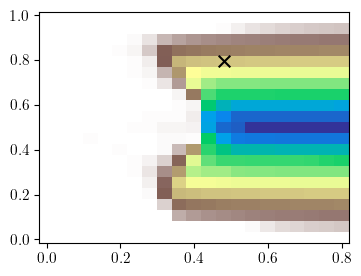

In [94]:
arg_J = np.argmin(np.abs(J_vals - J_to_explore))
arg_filling = np.argmin(np.abs(fillings - filling_to_explore))


fig, ax = plt.subplots(1, 1, figsize=(4, 3))
im0 = ax.pcolor(J, FIL, all_avg_mags, cmap="terrain_r")
ax.scatter(
    J_vals[arg_J],
    fillings[arg_filling],
    color="k",
    s=70,
    marker="x",
    zorder=10,
)

Now we can recalculate the hamiltonian to check that it was well-converged

In [95]:
parameters_at_point = data["params"][arg_filling, arg_J]
parameters_for_run = {
    "t1": parameters_at_point["t1"],
    "t2": parameters_at_point["t2"],
    "J": parameters_at_point["J"],
    "U": parameters_at_point["U"],
    "filling": parameters_at_point["filling"],
    "initial_m": parameters_at_point["m"],
    "initial_n": parameters_at_point["n"],
    "theta_offset": 0,
}

# first check how converged we are
m_new, n_new = hartree_fock(
    lattice, parameters_for_run, 100, adjust_learning_rate=False
)

# calculate the energies
ham = alt_hamiltonian(
    lattice,
    parameters_for_run["t1"],
    parameters_for_run["t2"],
    parameters_for_run["J"],
    parameters_for_run["U"],
    m_new[-1],
    n_new[-1],
)
energies_at_point, states_at_point = la.eigh(ham)

  0%|          | 0/100 [00:00<?, ?it/s]

Avg:0.80, diff: 0.000000:   8%|▊         | 8/100 [00:15<02:53,  1.89s/it]


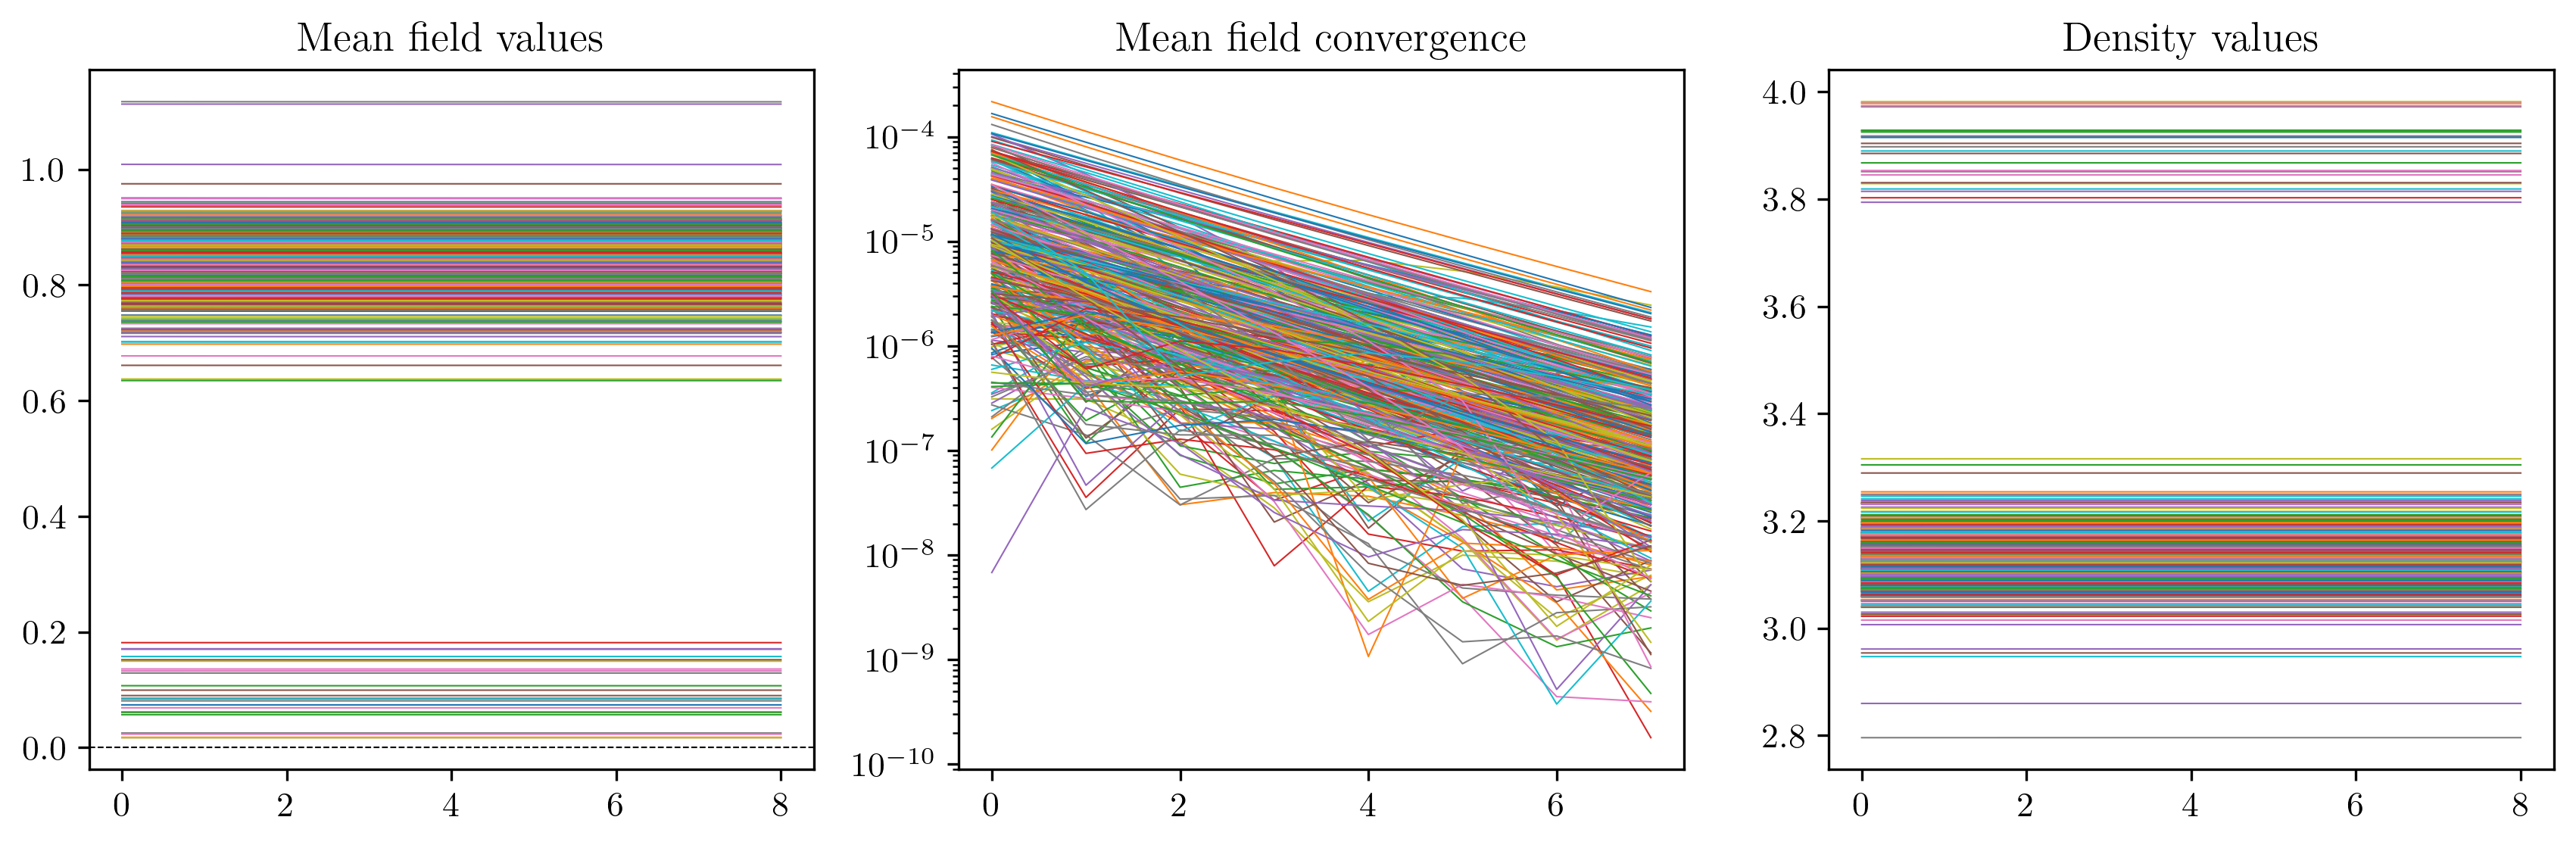

In [96]:
# plot the convergence
fig, ax = plt.subplots(1, 3, figsize=(14, 4), dpi=300)
ax[0].plot(m_new, linewidth=0.5)
ax[0].axhline(0, linestyle="--", color="black", linewidth=0.5)

diffs = np.diff(m_new, axis=0)
ax[1].plot(np.abs(diffs), linewidth=0.5)

ax[2].plot(n_new, linewidth=0.5)

ax[0].set_title("Mean field values")
ax[1].set_title("Mean field convergence")
ax[1].set_yscale("log")
ax[2].set_title("Density values")
plt.show()

Now we can show the Magnetisation, occupation, spectrum and density at the Fermi level

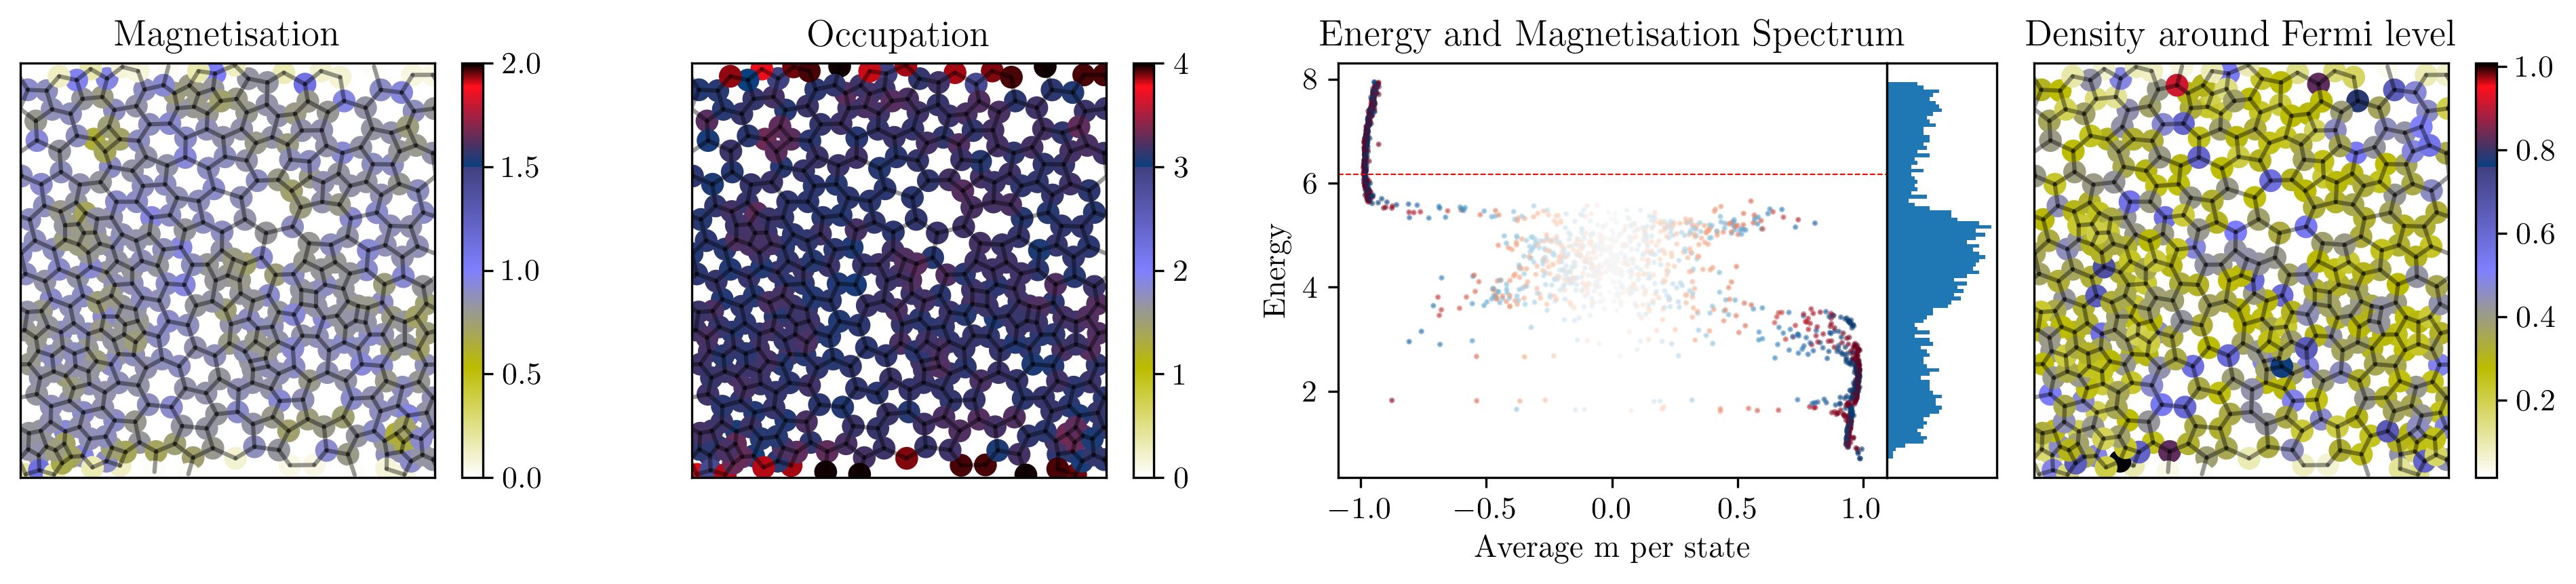

In [97]:
fermi_energy = fermi_level(energies_at_point, filling_to_explore)
fermi_occupation = np.heaviside(fermi_energy - energies_at_point, 0.5)

real_space_occupation = fermi_occupation[None, :] * (
    states_at_point * states_at_point.conj()
)
average_occupation = np.sum(real_space_occupation, axis=1)
average_occupation = average_occupation.reshape(-1, 4).sum(axis=-1)

rs_fermi_denisty = real_space_density_around_fermi(
    energies_at_point, states_at_point, fermi_energy, broadening
)


# plotting
fig, ax = plt.subplots(1, 4, figsize=(13, 3), dpi=300)

average_m_per_state = find_m_per_state(states_at_point)
average_spin_per_state = find_spin_per_state(states_at_point)

m_values_out = m_new[-1]
if np.any(m_values_out < 0):
    m_vrange = [-2, 2]
else:
    m_vrange = [0, 2]

vertices = lattice.vertices.positions
pl.plot_edges(lattice, ax=ax[0], alpha=0.4)
im = ax[0].scatter(
    vertices[:, 0],
    vertices[:, 1],
    c=m_values_out,
    cmap="gist_stern_r",
    s=50,
    vmin=m_vrange[0],
    vmax=m_vrange[1],
)
plt.colorbar(im, ax=ax[0])
ax[0].set_aspect("equal")
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title("Magnetisation")


pl.plot_edges(lattice, ax=ax[1], alpha=0.4)
im = ax[1].scatter(
    vertices[:, 0],
    vertices[:, 1],
    c=average_occupation,
    cmap="gist_stern_r",
    s=50,
    vmin=0,
    vmax=4,
)
plt.colorbar(im, ax=ax[1])
ax[1].set_aspect("equal")
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title("Occupation")

im = ax[2].scatter(
    average_m_per_state,
    energies_at_point,
    s=1,
    c=average_spin_per_state,
    cmap="RdBu",
    alpha=0.5,
)
ax[2].set_xlabel("Average m per state")
ax[2].set_ylabel("Energy")


ax_histy = ax[2].inset_axes([1.0, 0, 0.2, 1])
ax[2].axhline(fermi_energy, color="r", linestyle="--", linewidth=0.5)
ax[2].set_title("Energy and Magnetisation Spectrum")
ax[2].yaxis.tick_left()
ax_histy.hist(energies_at_point, bins=100, orientation="horizontal")
ax_histy.set_xticks([])
ax_histy.set_yticks([])

pl.plot_edges(lattice, ax=ax[3], alpha=0.4)

im = ax[3].scatter(
    vertices[:, 0],
    vertices[:, 1],
    c=rs_fermi_denisty,
    cmap="gist_stern_r",
    s=50,
)
plt.colorbar(im, ax=ax[3])
ax[3].set_aspect("equal")
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title("Density around Fermi level")

plt.tight_layout()

Next we find the spectral functions at the fermi energy

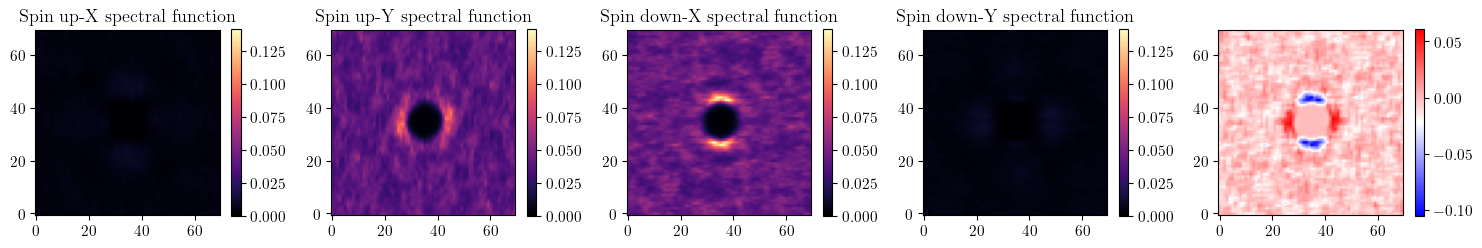

In [98]:
energy_to_look_at = fermi_energy
broadening = 0.1
specs = [
    spectral_function(
        lattice,
        energies_at_point,
        states_at_point,
        energy_to_look_at,
        local_operator=np.eye(4)[i],
        eta=broadening,
        n_k=70,
    )
    for i in range(4)
]
subtracted = specs[0] + specs[1] - specs[2] - specs[3]

#  plotting
fig, ax = plt.subplots(1, 5, figsize=(15, 2.4))
k_limits = 35

kx = np.arange(-k_limits, k_limits)
ky = np.arange(-k_limits, k_limits)


cmin = np.min(specs)
cmax = np.max(specs)

for n, a in enumerate(ax.flatten()[:4]):
    im = a.imshow(
        specs[n],
        cmap="magma",
        origin="lower",
        vmin=cmin,
        vmax=cmax,
    )
    # add colorbar
    plt.colorbar(im, ax=a)


ax[0].set_title("Spin up-X spectral function")
ax[1].set_title("Spin up-Y spectral function")
ax[2].set_title("Spin down-X spectral function")
ax[3].set_title("Spin down-Y spectral function")

im = ax[4].imshow(
    subtracted,
    cmap="bwr",
    origin="lower",
)

plt.colorbar(im, ax=ax[4])

plt.tight_layout()
plt.show()

Finally, let's calculate the conductance and the spin conductance

100%|██████████| 20/20 [00:05<00:00,  4.00it/s]


Text(0, 0.5, 'Conductance')

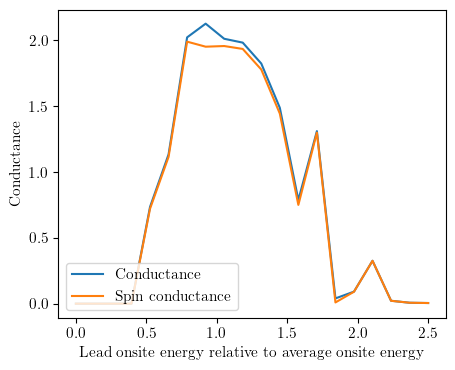

In [143]:
lead_onsite_back = np.mean(
    [ham[i * 4 : (i + 1) * 4, i * 4 : (i + 1) * 4] for i in range(lattice.n_vertices)],
    axis=0,
)

conductances = []
spin_conductances = []

a_vals = np.linspace(0, 2.5, 20)
for a in tqdm(a_vals):

    lead_onsite = lead_onsite_back * a
    lead_coupling = -np.eye(4)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, ham)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice,
        k_lattice,
        k_system,
        contact_vertices,
        lead_onsite,
        lead_coupling,
        np.diag([-1, -1, 1, 1]),
    )

    k_system_f = k_system.finalized()

    smatrix = kwant.smatrix(k_system_f, energy=fermi_energy)
    g = np.array(
        [[smatrix.transmission((1, j), (0, i)) for j in range(2)] for i in range(2)]
    )
    cond = g[0, 0] + g[1, 1]
    s_cond = g[0, 0] - g[1, 1]

    conductances.append(cond)
    spin_conductances.append(s_cond)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(a_vals, conductances, label="Conductance")
ax.plot(a_vals, spin_conductances, label="Spin conductance")
ax.legend(loc="lower left")

ax.set_xlabel("Lead onsite energy relative to average onsite energy")
ax.set_ylabel("Conductance")